# 9. Investigate effect of the loss function 

1. Reproduce example presented during the lecture (trade signal) 

2. Check what happens when: 

    a. The quadratic part of the loss function is disabled 

    b. The coefficient by which the quadratic part is multiplied is changed to: 

    * i. 500 

    * ii. 1000 

    Explain. 

In [33]:
import numpy as np
import pymc as pm
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas
import arviz as az
from scipy.optimize import fmin

1. Reproduce example presented during the lecture (trade signal) 


In [15]:
df = pandas.read_excel('../data/data_l9.xlsx')
df

,Unnamed: 0,X,Y
0,0,-0.015981,0.001984
1,1,-0.012942,-0.000511
2,2,-0.018796,0.008553
3,3,-0.019340,-0.019842
4,4,0.015664,-0.002325
...,...,...,...
95,95,0.020906,-0.005031
96,96,0.014225,0.010354
97,97,0.043465,0.033145
98,98,-0.051574,-0.033425


In [16]:
X, y = df['X'].values.reshape(-1, 1), df['Y'].values
X.shape, y.shape

((100, 1), (100,))

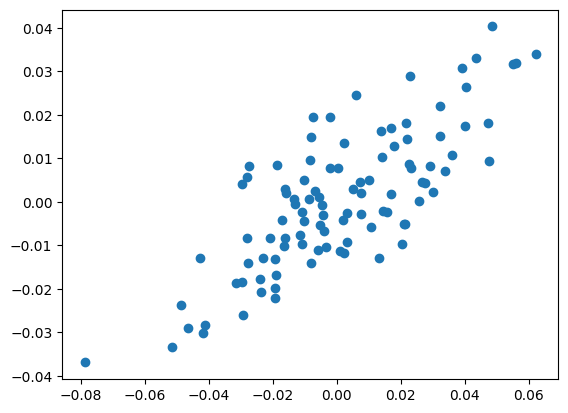

In [17]:
plt.scatter(X, y)
plt.show()

In [35]:
print(f"Y range: {y.min()} to {y.max()}")
print(f"Y std: {y.std()}")

Y range: -0.03693422430887111 to 0.04034093639238249
Y std: 0.015855972462715345


In [18]:
reg = LinearRegression().fit(X, y)
reg.score(X, y)

0.612109542662326

In [19]:
reg.coef_, reg.intercept_

(array([0.46875985]), np.float64(0.00016331182377491652))

In [20]:
def stock_loss(factual, predicted, coef = 100.):
    if factual * predicted < 0:
        return coef * predicted**2 + abs(factual - predicted)
    else:
        return abs(factual - predicted)

In [21]:
def stock_loss_vect(factual_vect, predicted, coef=100):
    loss_vect = np.zeros_like(factual_vect)
    ix_vect = factual_vect * predicted < 0
    loss_vect[ix_vect] = coef * predicted ** 2 + abs(factual_vect[ix_vect] - predicted)
    loss_vect[~ix_vect] = abs(factual_vect[~ix_vect] - predicted)
    return loss_vect.mean()

## Bayesian Linear Regression Model


In [ ]:
# Flatten X for PyMC
X_flat = X.flatten()

with pm.Model() as model:
    # Priors
    std = pm.Uniform("std", 0, 100)
    beta = pm.Normal("beta", mu=0, sigma=100)
    alpha = pm.Normal("alpha", mu=0, sigma=100)
    
    # Linear regression
    mean = pm.Deterministic("mean", alpha + beta * X_flat)
    
    # Likelihood
    obs = pm.Normal("obs", mu=mean, sigma=std, observed=y)
    
    # Sampling
    idata = pm.sample(2000, tune=1000, return_inferencedata=True, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [std, beta, alpha]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 235 seconds.


In [23]:
# Check the posterior distributions
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,0.469,0.038,0.399,0.540,0.0,0.0,12014.0,6257.0,1.0
alpha,0.000,0.001,-0.002,0.002,0.0,0.0,10812.0,6147.0,1.0
std,0.010,0.001,0.009,0.012,0.0,0.0,11415.0,6010.0,1.0
mean[0],-0.007,0.001,-0.010,-0.005,0.0,0.0,10965.0,6399.0,1.0
mean[1],-0.006,0.001,-0.008,-0.004,0.0,0.0,10723.0,6494.0,1.0
...,...,...,...,...,...,...,...,...,...
mean[95],0.010,0.001,0.008,0.012,0.0,0.0,11502.0,5277.0,1.0
mean[96],0.007,0.001,0.005,0.009,0.0,0.0,11251.0,5202.0,1.0
mean[97],0.021,0.002,0.017,0.024,0.0,0.0,11909.0,5583.0,1.0
mean[98],-0.024,0.002,-0.028,-0.020,0.0,0.0,11586.0,6088.0,1.0


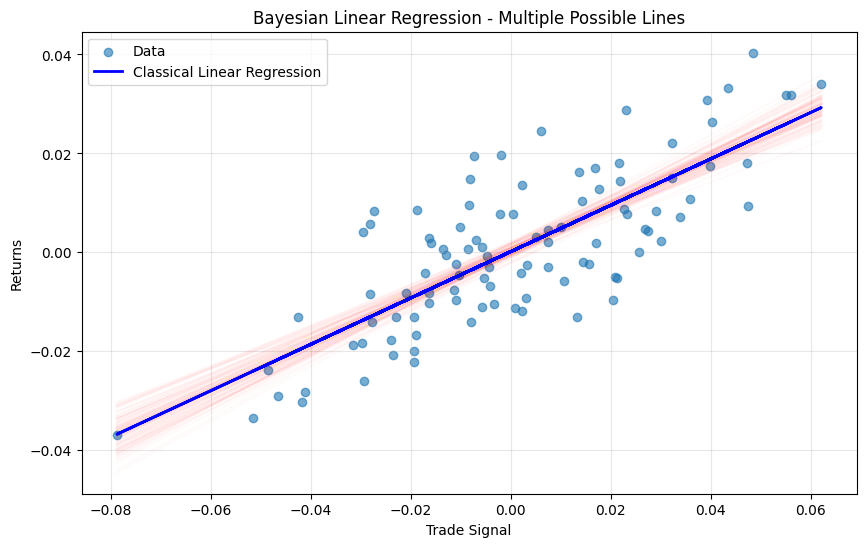

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X, y, alpha=0.6, label='Data')

alpha_samples = idata.posterior['alpha'].values.flatten()
beta_samples = idata.posterior['beta'].values.flatten()

for i in range(0, len(alpha_samples), len(alpha_samples)//100):
    x_line = np.linspace(X.min(), X.max(), 100)
    y_line = alpha_samples[i] + beta_samples[i] * x_line
    ax.plot(x_line, y_line, 'r-', alpha=0.02)

ax.plot(X, reg.predict(X), 'b-', linewidth=2, label='Classical Linear Regression')

ax.set_xlabel('Trade Signal')
ax.set_ylabel('Returns')
ax.set_title('Bayesian Linear Regression - Multiple Possible Lines')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Custom Loss

In [ ]:
def optimize_predictions(coef=100):

    # Extract posterior samples
    # each sample vector has possible values for std, alpha, beta
    # the more samples that are similar, the more likely they are
    std_samples = idata.posterior['std'].values.flatten()
    alpha_samples = idata.posterior['alpha'].values.flatten()
    beta_samples = idata.posterior['beta'].values.flatten()
    
    N = len(std_samples)
    
    # Generate noise from posterior std
    noise = std_samples * np.random.randn(N)
    
    # Create trade signals to test
    trade_signals = np.linspace(X.min(), X.max(), 50)
    opt_predictions = np.zeros(50)
    
    # For each trade signal, find optimal prediction
    for i, signal in enumerate(trade_signals):
        # Generate possible outcomes based on posterior
        possible_outcomes = alpha_samples + beta_samples * signal + noise
        
        # Minimize loss
        def tomin(pred):
            return stock_loss_vect(possible_outcomes, pred, coef=coef)
        
        opt_predictions[i] = fmin(tomin, 0, disp=False)
    
    return trade_signals, opt_predictions

### Original Loss (coef = 100)

C:\Users\bilbo\AppData\Local\Temp\ipykernel_18528\382003972.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  opt_predictions[i] = fmin(tomin, 0, disp=False)


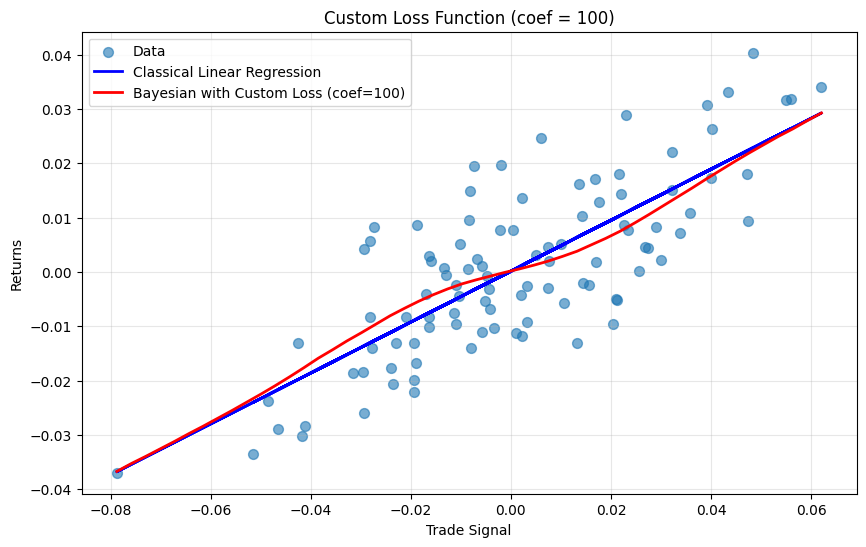

In [45]:
trade_signals_100, opt_predictions_100 = optimize_predictions(coef=100)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X, y, alpha=0.6, label='Data', s=50)
ax.plot(X, reg.predict(X), 'b-', linewidth=2, label='Classical Linear Regression')
ax.plot(trade_signals_100, opt_predictions_100, 'r-', linewidth=2, label='Bayesian with Custom Loss (coef=100)')
ax.set_xlabel('Trade Signal')
ax.set_ylabel('Returns')
ax.set_title('Custom Loss Function (coef = 100)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### Quadratic Part Disabled (coef = 0)

When the quadratic part is disabled, the loss becomes linear, beacause it is.

C:\Users\bilbo\AppData\Local\Temp\ipykernel_18528\382003972.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  opt_predictions[i] = fmin(tomin, 0, disp=False)


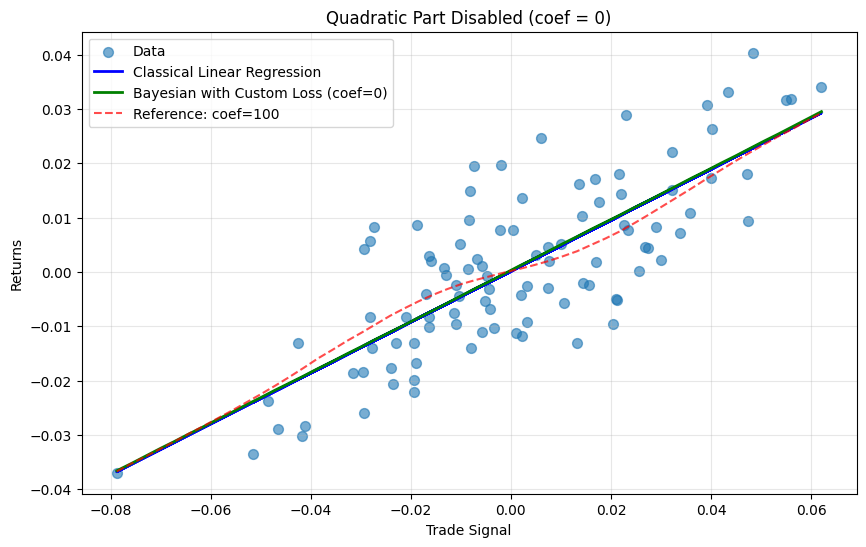

In [46]:
trade_signals_0, opt_predictions_0 = optimize_predictions(coef=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X, y, alpha=0.6, label='Data', s=50)
ax.plot(X, reg.predict(X), 'b-', linewidth=2, label='Classical Linear Regression')
ax.plot(trade_signals_0, opt_predictions_0, 'g-', linewidth=2, label='Bayesian with Custom Loss (coef=0)')
ax.plot(trade_signals_100, opt_predictions_100, 'r--', linewidth=1.5, alpha=0.7, label='Reference: coef=100')
ax.set_xlabel('Trade Signal')
ax.set_ylabel('Returns')
ax.set_title('Quadratic Part Disabled (coef = 0)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### Increased Coefficient (coef = 500)

C:\Users\bilbo\AppData\Local\Temp\ipykernel_18528\1854384357.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  opt_predictions[i] = fmin(tomin, 0, disp=False)


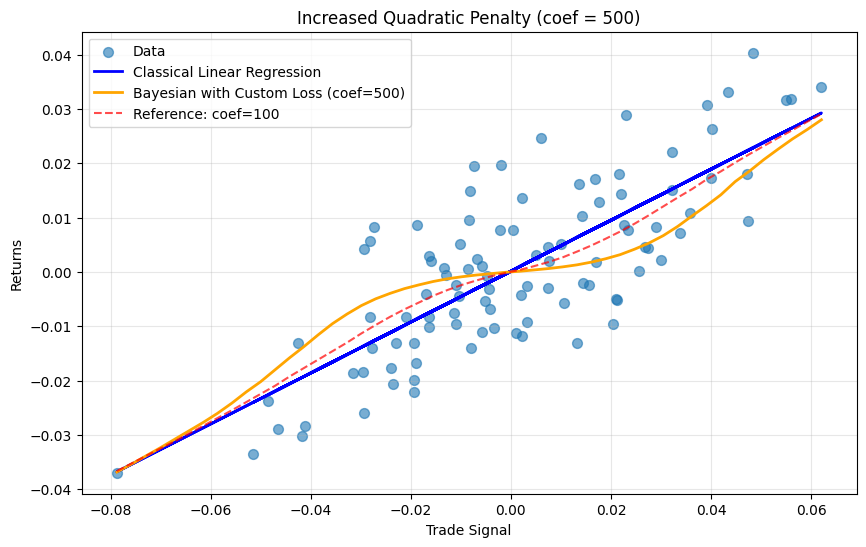

In [31]:
trade_signals_500, opt_predictions_500 = optimize_predictions(coef=500)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X, y, alpha=0.6, label='Data', s=50)
ax.plot(X, reg.predict(X), 'b-', linewidth=2, label='Classical Linear Regression')
ax.plot(trade_signals_500, opt_predictions_500, 'orange', linewidth=2, label='Bayesian with Custom Loss (coef=500)')
ax.plot(trade_signals_100, opt_predictions_100, 'r--', linewidth=1.5, alpha=0.7, label='Reference: coef=100')
ax.set_xlabel('Trade Signal')
ax.set_ylabel('Returns')
ax.set_title('Increased Quadratic Penalty (coef = 500)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### Further Increased Coefficient (coef = 1000)

C:\Users\bilbo\AppData\Local\Temp\ipykernel_18528\1854384357.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  opt_predictions[i] = fmin(tomin, 0, disp=False)


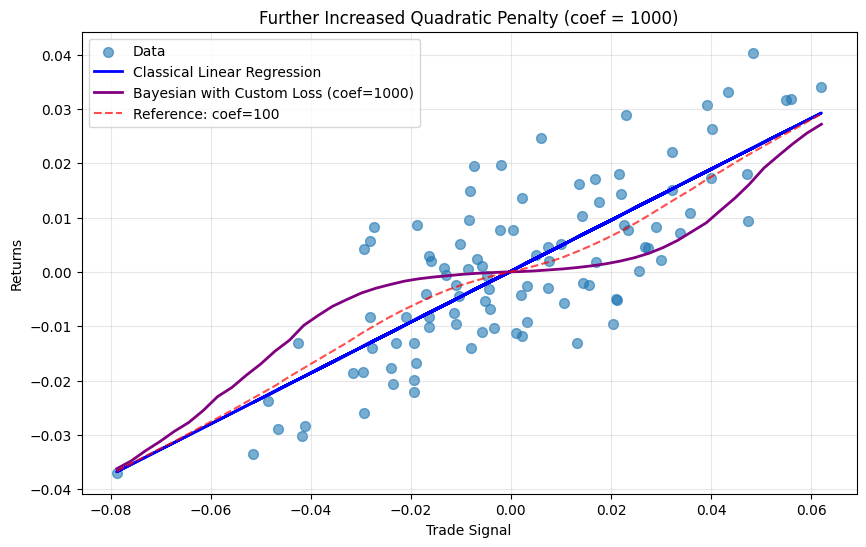

In [30]:
trade_signals_1000, opt_predictions_1000 = optimize_predictions(coef=1000)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X, y, alpha=0.6, label='Data', s=50)
ax.plot(X, reg.predict(X), 'b-', linewidth=2, label='Classical Linear Regression')
ax.plot(trade_signals_1000, opt_predictions_1000, 'purple', linewidth=2, label='Bayesian with Custom Loss (coef=1000)')
ax.plot(trade_signals_100, opt_predictions_100, 'r--', linewidth=1.5, alpha=0.7, label='Reference: coef=100')
ax.set_xlabel('Trade Signal')
ax.set_ylabel('Returns')
ax.set_title('Further Increased Quadratic Penalty (coef = 1000)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Conclusions

When the predicted value and actual value have the same sign (both negative - shorting and the stock falls), the error is calculated linearly as |factual - predicted|.

When the predicted value and actual value have different signs (predicted growth but the stock fell), the error is drastically increased quadratically multiplied by the coefficient - which heavily penalizes such behavior.

The larger the coefficient, the more conservative our model becomes, preferring to increase the uncertainty area due to natural noise in the data. However, the function eventually tends toward linear, which indicates an overall linear trend in the data.